# Prétraitement des Images (Masked Face Super Resolution)

Ce notebook propose un pipeline de prétraitement complet pour préparer les images masquées et originales avant de les passer aux modèles (Autoencodeurs, GANs, Diffusion).

## Objectifs du prétraitement :
1. **Détection et recadrage du visage (Face Cropping)** : Isoler le visage en le détectant sur l'image non-masquée pour supprimer l'arrière-plan inutile, puis appliquer la même découpe sur l'image masquée.
2. **Redimensionnement uniforme** : S'assurer que toutes les images ont la même taille (ex: 128x128 ou 256x256).
3. **Normalisation** : Ramener les valeurs de pixels de [0, 255] à [-1, 1] ou [0, 1] pour stabiliser l'apprentissage des réseaux de neurones.
4. **Conversion en Tenseurs PyTorch** : Format requis pour l'entraînement.

In [21]:
import os
import shutil

# Configuration des dossiers de destination pour le prétraitement
DATA_DIR = '../data'
SRC_DATA_DIR = '../src/data' # Nouveau chemin pour les données prétraitées
MASKED_DIR = os.path.join(DATA_DIR, 'Masked')
UNMASKED_DIR = os.path.join(DATA_DIR, 'Unmasked')
MASKED_OUT_DIR = os.path.join(SRC_DATA_DIR, 'Masked_pretraiter')
UNMASKED_OUT_DIR = os.path.join(SRC_DATA_DIR, 'UnMasked_pretraiter')

# Création des répertoires s'ils n'existent pas
os.makedirs(MASKED_OUT_DIR, exist_ok=True)
os.makedirs(UNMASKED_OUT_DIR, exist_ok=True)
print(f"Dossiers de prétraitement prêts:\n- {MASKED_OUT_DIR}\n- {UNMASKED_OUT_DIR}\n")

# Fonction pour copier le contenu d'un dossier vers l'autre
def copy_images(src_dir, dst_dir):
    if not os.path.exists(src_dir):
        print(f"Dossier source introuvable : {src_dir}")
        return 0
        
    count = 0
    for filename in os.listdir(src_dir):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            src_path = os.path.join(src_dir, filename)
            dst_path = os.path.join(dst_dir, filename)
            shutil.copy2(src_path, dst_path)
            count += 1
    return count

copied_m = copy_images(MASKED_DIR, MASKED_OUT_DIR)
copied_u = copy_images(UNMASKED_DIR, UNMASKED_OUT_DIR)

Dossiers de prétraitement prêts:
- ../src/data\Masked_pretraiter
- ../src/data\UnMasked_pretraiter



## Etape 1 : Détection et recadrage du visage (Face Cropping)

In [22]:
import cv2
import os
import re

MASKED_OUT_DIR = '../src/data/Masked_pretraiter'
UNMASKED_OUT_DIR = '../src/data/UnMasked_pretraiter'

# Charger le détecteur de visage OpenCV (Haar Cascade)
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

def apply_face_cropping_inplace(u_path, m_path, margin=0.2):
    """
    Détecte le visage sur l'image Non Masquée (u_path) pour éviter que le masque gêne,
    puis recadre les deux images aux mêmes dimensions. Remplace les fichiers.
    """
    img_u = cv2.imread(u_path)
    img_m = cv2.imread(m_path)
    
    if img_u is None or img_m is None: 
        return False
        
    gray = cv2.cvtColor(img_u, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    if len(faces) > 0:
        # Prendre le visage le plus grand
        (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])
        
        # Marge pour ne pas couper le menton/front
        x_m = int(w * margin)
        y_m = int(h * margin)
        
        x1, y1 = max(0, x - x_m), max(0, y - y_m)
        x2, y2 = min(img_u.shape[1], x + w + x_m), min(img_u.shape[0], y + h + y_m)
        
        crop_u = img_u[y1:y2, x1:x2]
        crop_m = img_m[y1:y2, x1:x2]
        
        # Écraser l'image copiée avec la version recadrée
        cv2.imwrite(u_path, crop_u)
        cv2.imwrite(m_path, crop_m)
        return True
        
    return False

def get_base_name(filename):
    match = re.match(r'^u?m_?(.*)$', filename, re.IGNORECASE)
    return match.group(1) if match else filename

# Lister et apparier les fichiers dans les dossiers de prétraitement
unmasked_files = {get_base_name(f): f for f in os.listdir(UNMASKED_OUT_DIR) if f.endswith(('.png', '.jpg'))}
masked_files = {get_base_name(f): f for f in os.listdir(MASKED_OUT_DIR) if f.endswith(('.png', '.jpg'))}
common_bases = set(unmasked_files.keys()).intersection(set(masked_files.keys()))

print(f"Début du recadrage sur {len(common_bases)} paires d'images...")
# On stocke ici la liste des fichiers qui ont été modifiés (recadrés avec succès)
cropped_bases = []

for base in list(common_bases):
    u_path = os.path.join(UNMASKED_OUT_DIR, unmasked_files[base])
    m_path = os.path.join(MASKED_OUT_DIR, masked_files[base])
    
    if apply_face_cropping_inplace(u_path, m_path):
        cropped_bases.append(base)

print(f"Terminé : {len(cropped_bases)} visages détectés et recadrés avec succès.")

Début du recadrage sur 330 paires d'images...
Terminé : 149 visages détectés et recadrés avec succès.


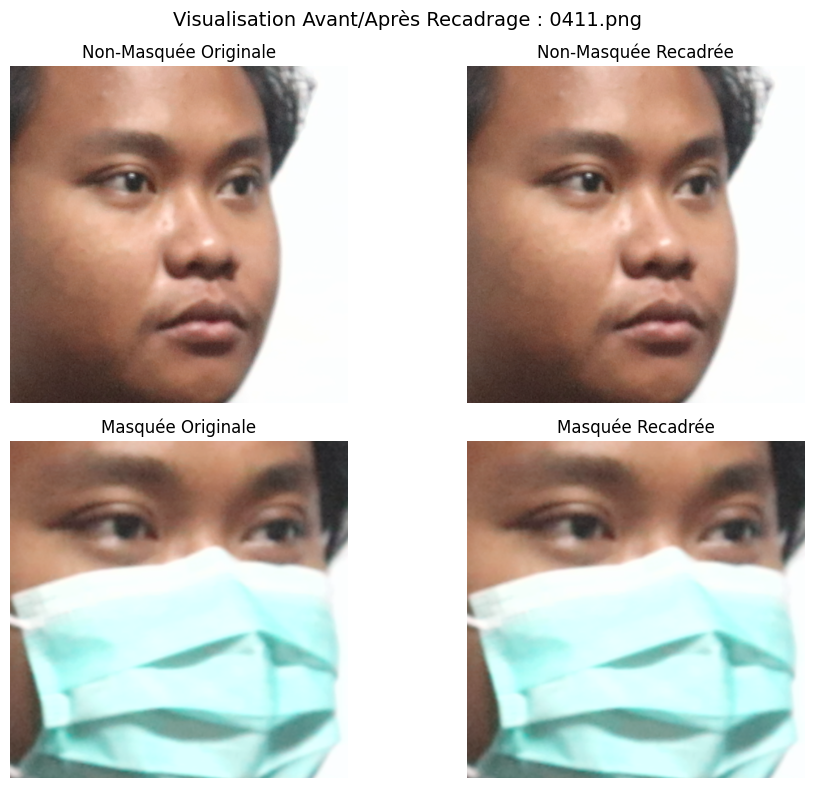

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# Visualisation Avant / Après aléatoire parmi les images effectivement modifiées
if len(cropped_bases) > 0:
    # On sélectionne un fichier au hasard parmi ceux recadrés
    sample_base = np.random.choice(cropped_bases)
    sample_u_file = unmasked_files[sample_base]
    sample_m_file = masked_files[sample_base]
    
    # Lecture des originaux
    orig_u = Image.open(os.path.join(UNMASKED_DIR, sample_u_file))
    orig_m = Image.open(os.path.join(MASKED_DIR, sample_m_file))
    
    # Lecture des versions recadrées
    proc_u = Image.open(os.path.join(UNMASKED_OUT_DIR, sample_u_file))
    proc_m = Image.open(os.path.join(MASKED_OUT_DIR, sample_m_file))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0,0].imshow(orig_u)
    axes[0,0].set_title("Non-Masquée Originale")
    axes[0,0].axis('off')
    
    axes[0,1].imshow(proc_u)
    axes[0,1].set_title("Non-Masquée Recadrée")
    axes[0,1].axis('off')

    axes[1,0].imshow(orig_m)
    axes[1,0].set_title("Masquée Originale")
    axes[1,0].axis('off')
    
    axes[1,1].imshow(proc_m)
    axes[1,1].set_title("Masquée Recadrée")
    axes[1,1].axis('off')
    
    plt.suptitle(f"Visualisation Avant/Après Recadrage : {sample_base}", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image recadrée à visualiser.")

## Etape 2 : Redimensionnement uniforme

In [24]:
import os
import cv2
import re

IMAGE_SIZE = 128 # Paramètre de redimensionnement 128x128

def apply_resize_inplace(u_path, m_path, target_size=(128, 128)):
    """
    Redimensionne les images Masquée et Non Masquée à la taille cible (128x128x3).
    Remplace les fichiers existants.Retourne True si un redimensionnement a eu lieu.
    """
    img_u = cv2.imread(u_path)
    img_m = cv2.imread(m_path)
    
    if img_u is None or img_m is None: 
        return False
        
    # On vérifie si la taille est déjà la bonne pour éviter des écritures inutiles
    resized = False
    if img_u.shape[:2] != target_size:
        img_u = cv2.resize(img_u, target_size, interpolation=cv2.INTER_AREA)
        cv2.imwrite(u_path, img_u)
        resized = True
        
    if img_m.shape[:2] != target_size:
        img_m = cv2.resize(img_m, target_size, interpolation=cv2.INTER_AREA)
        cv2.imwrite(m_path, img_m)
        resized = True
        
    return resized

# Appariement (identique à l'étape précédente)
unmasked_files = {get_base_name(f): f for f in os.listdir(UNMASKED_OUT_DIR) if f.endswith(('.png', '.jpg'))}
masked_files = {get_base_name(f): f for f in os.listdir(MASKED_OUT_DIR) if f.endswith(('.png', '.jpg'))}
common_bases = set(unmasked_files.keys()).intersection(set(masked_files.keys()))

print(f"Début du redimensionnement vers {IMAGE_SIZE}x{IMAGE_SIZE}...")
# Stockage des fichiers qui ont été modifiés lors du redimensionnement
resized_bases = []

for base in list(common_bases):
    u_path = os.path.join(UNMASKED_OUT_DIR, unmasked_files[base])
    m_path = os.path.join(MASKED_OUT_DIR, masked_files[base])
    
    # On passe notre tuple de taille
    if apply_resize_inplace(u_path, m_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)):
        resized_bases.append(base)

print(f"Terminé : {len(resized_bases)} paires d'images redimensionnées.")

Début du redimensionnement vers 128x128...
Terminé : 330 paires d'images redimensionnées.


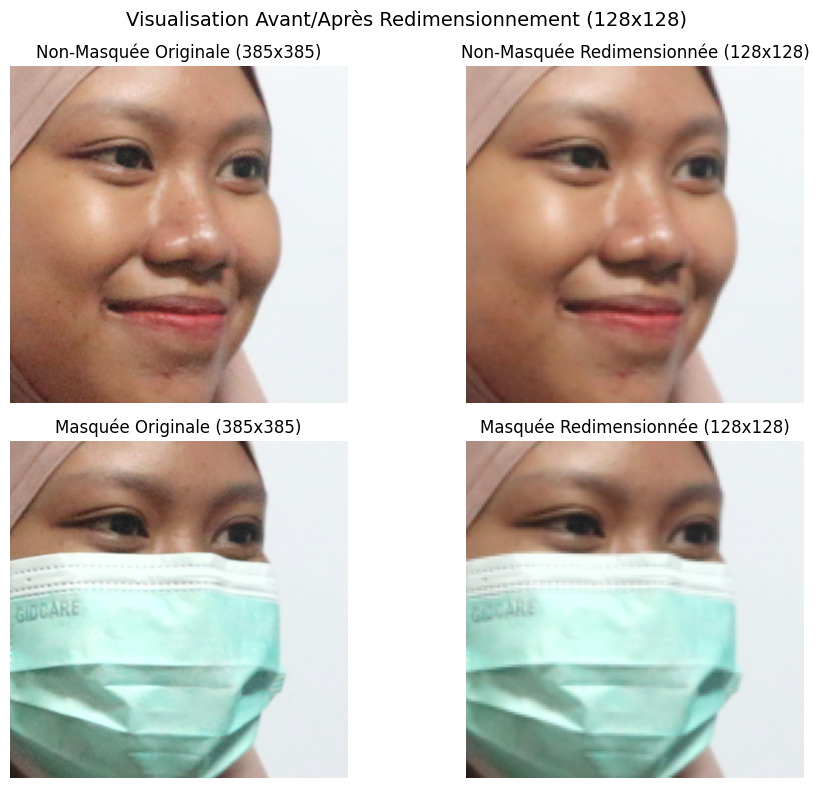

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# Visualisation Avant / Après aléatoire parmi les images effectivement redimensionnées
if len(resized_bases) > 0:
    # On sélectionne un fichier au hasard parmi ceux redimensionnés
    sample_base = np.random.choice(resized_bases)
    sample_u_file = unmasked_files[sample_base]
    sample_m_file = masked_files[sample_base]
    
    # Lecture des originaux bruts
    orig_u = Image.open(os.path.join(UNMASKED_DIR, sample_u_file))
    orig_m = Image.open(os.path.join(MASKED_DIR, sample_m_file))
    
    # Lecture des versions redimensionnées (depuis les dossiers de prétraitement)
    proc_u = Image.open(os.path.join(UNMASKED_OUT_DIR, sample_u_file))
    proc_m = Image.open(os.path.join(MASKED_OUT_DIR, sample_m_file))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0,0].imshow(orig_u)
    # Affichage de la dimension d'origine pour constater le changement
    axes[0,0].set_title(f"Non-Masquée Originale ({orig_u.size[0]}x{orig_u.size[1]})")
    axes[0,0].axis('off')
    
    axes[0,1].imshow(proc_u)
    # Dimensions finales
    axes[0,1].set_title(f"Non-Masquée Redimensionnée ({proc_u.size[0]}x{proc_u.size[1]})")
    axes[0,1].axis('off')

    axes[1,0].imshow(orig_m)
    axes[1,0].set_title(f"Masquée Originale ({orig_m.size[0]}x{orig_m.size[1]})")
    axes[1,0].axis('off')
    
    axes[1,1].imshow(proc_m)
    axes[1,1].set_title(f"Masquée Redimensionnée ({proc_m.size[0]}x{proc_m.size[1]})")
    axes[1,1].axis('off')
    
    plt.suptitle(f"Visualisation Avant/Après Redimensionnement ({IMAGE_SIZE}x{IMAGE_SIZE})", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image n'a été redimensionnée.")

## Etape 3 : Normalisation et conversion en Tenseurs PyTorch

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms

normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

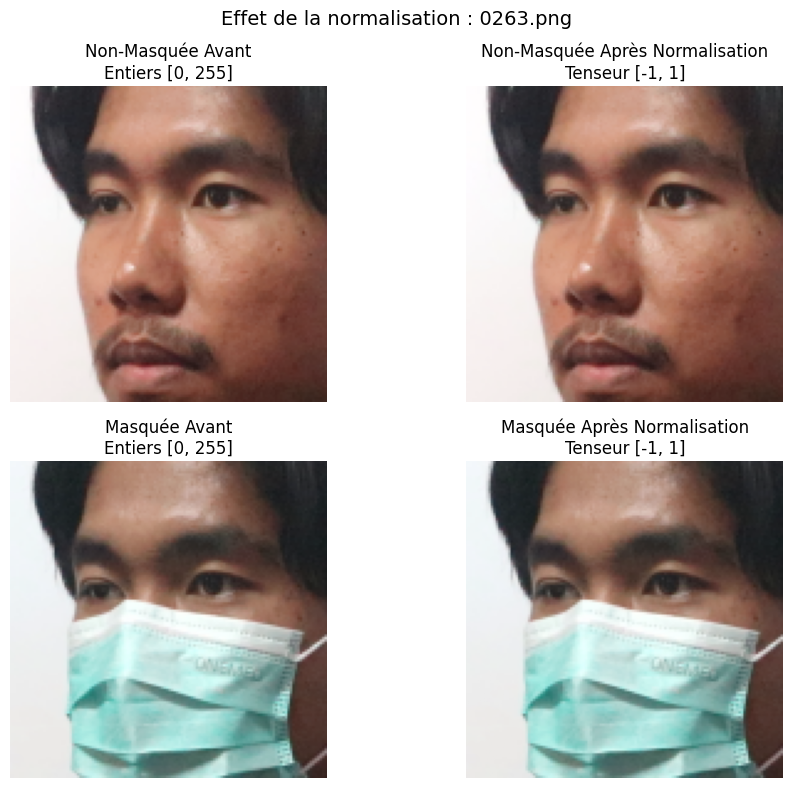

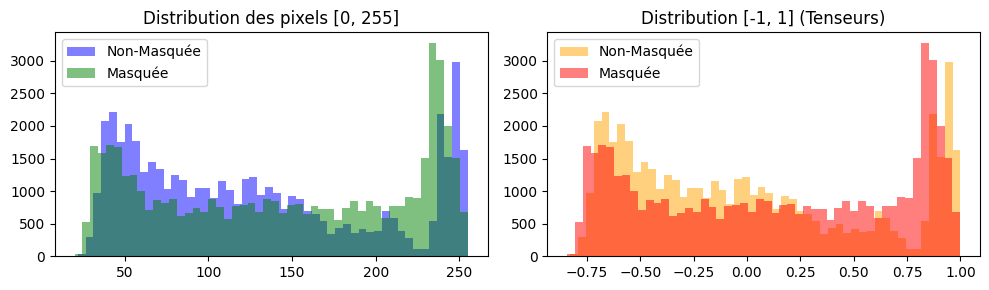

In [27]:
if 'resized_bases' in locals() and len(resized_bases) > 0:
    sample_base = np.random.choice(resized_bases)
    img_u_path = os.path.join(UNMASKED_OUT_DIR, unmasked_files[sample_base])
    img_m_path = os.path.join(MASKED_OUT_DIR, masked_files[sample_base])
    
    # 1. Images d'origine (après crop et resize) - Format [0, 255]
    img_u_pil = Image.open(img_u_path).convert('RGB')
    img_u_array = np.array(img_u_pil)
    
    img_m_pil = Image.open(img_m_path).convert('RGB')
    img_m_array = np.array(img_m_pil)
    
    # 2. Images normalisées - Format [-1, 1]
    img_u_tensor = normalize_transform(img_u_pil)
    img_m_tensor = normalize_transform(img_m_pil)
    
    # Pour afficher l'image normalisée avec plt.imshow, il faut la ramener dans [0, 1]
    def tensor_to_display(tensor):
        img_display = tensor.numpy().transpose(1, 2, 0)
        img_display = (img_display * 0.5) + 0.5 
        return np.clip(img_display, 0, 1)

    img_u_display = tensor_to_display(img_u_tensor)
    img_m_display = tensor_to_display(img_m_tensor)

    # === Visualisation des Images ===
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0,0].imshow(img_u_array)
    axes[0,0].set_title(f"Non-Masquée Avant\nEntiers [0, 255]")
    axes[0,0].axis('off')
    
    axes[0,1].imshow(img_u_display)
    axes[0,1].set_title(f"Non-Masquée Après Normalisation\nTenseur [-1, 1]")
    axes[0,1].axis('off')

    axes[1,0].imshow(img_m_array)
    axes[1,0].set_title(f"Masquée Avant\nEntiers [0, 255]")
    axes[1,0].axis('off')
    
    axes[1,1].imshow(img_m_display)
    axes[1,1].set_title(f"Masquée Après Normalisation\nTenseur [-1, 1]")
    axes[1,1].axis('off')
    
    plt.suptitle(f"Effet de la normalisation : {sample_base}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # === Visualisation des Histogrammes (Répartition des pixels) ===
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    axes[0].hist(img_u_array.ravel(), bins=50, color='blue', alpha=0.5, label='Non-Masquée')
    axes[0].hist(img_m_array.ravel(), bins=50, color='green', alpha=0.5, label='Masquée')
    axes[0].set_title("Distribution des pixels [0, 255]")
    axes[0].legend()
    
    axes[1].hist(img_u_tensor.numpy().ravel(), bins=50, color='orange', alpha=0.5, label='Non-Masquée')
    axes[1].hist(img_m_tensor.numpy().ravel(), bins=50, color='red', alpha=0.5, label='Masquée')
    axes[1].set_title("Distribution [-1, 1] (Tenseurs)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Aucune image disponible. Veuillez d'abord exécuter l'étape 2 (Redimensionnement).")

## Etape 4 : Visualisation

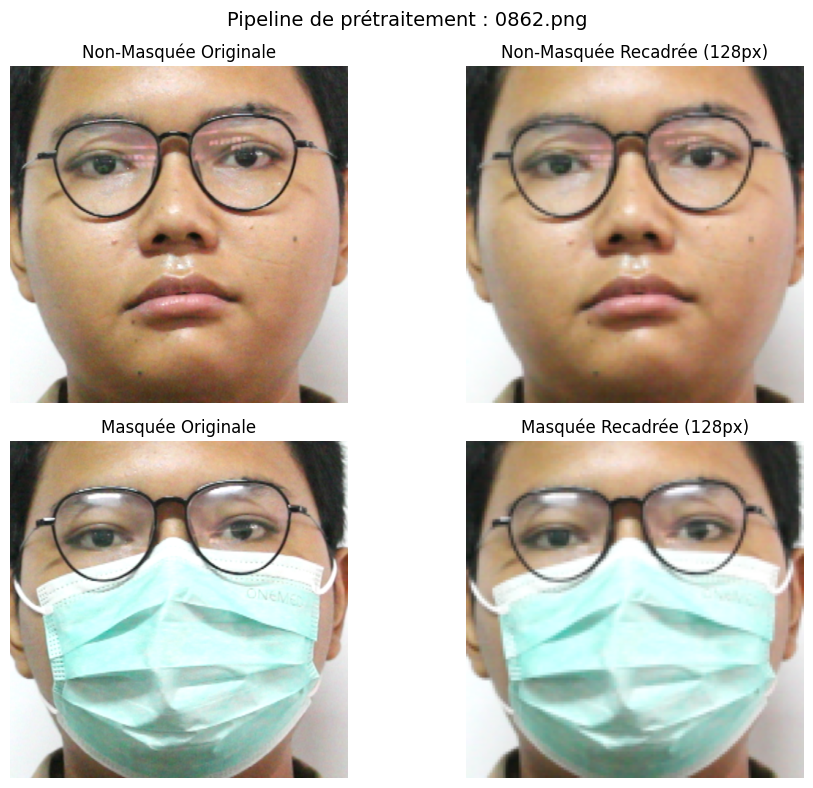

In [28]:
# 3. Visualisation Avant / Après aléatoire
if len(common_bases) > 0:
    sample_base = np.random.choice(list(common_bases))
    sample_u_file = unmasked_files[sample_base]
    sample_m_file = masked_files[sample_base]
    
    orig_u = Image.open(os.path.join(UNMASKED_DIR, sample_u_file))
    proc_u = Image.open(os.path.join(UNMASKED_OUT_DIR, sample_u_file))
    orig_m = Image.open(os.path.join(MASKED_DIR, sample_m_file))
    proc_m = Image.open(os.path.join(MASKED_OUT_DIR, sample_m_file))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0,0].imshow(orig_u)
    axes[0,0].set_title(f"Non-Masquée Originale")
    axes[0,0].axis('off')
    
    axes[0,1].imshow(proc_u)
    axes[0,1].set_title(f"Non-Masquée Recadrée ({IMAGE_SIZE}px)")
    axes[0,1].axis('off')

    axes[1,0].imshow(orig_m)
    axes[1,0].set_title(f"Masquée Originale")
    axes[1,0].axis('off')
    
    axes[1,1].imshow(proc_m)
    axes[1,1].set_title(f"Masquée Recadrée ({IMAGE_SIZE}px)")
    axes[1,1].axis('off')
    
    plt.suptitle(f"Pipeline de prétraitement : {sample_base}", fontsize=14)
    plt.tight_layout()
    plt.show()